# 01 Exploratory Data Analysis

Characterises `combined_dataset.csv` (DEPTWEET Twitter + Reddit Depression Severity, N=10,404).  
All splits (80/10/10, stratified on label × source, seed=42) were fixed prior to this analysis, findings  
describe the dataset and motivate design choices but do not alter them.

**Sections**  
1. Dataset overview  
2. Label distribution  
3. Source distribution & platform × label breakdown  
4. Text length analysis  
5. Class imbalance & class-weight derivation  
6. Informality score distribution  
7. Representative examples per class  
8. Key findings summary

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sys.path.insert(0, str(Path("..").resolve()))

from src.slang import add_informality_score

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
LABEL_ORDER   = ['minimum', 'mild', 'moderate', 'severe']
LABEL_COLOURS = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']
FIG_DIR = Path("../results/figures/eda")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Imports OK")

Imports OK


---
## 1. Dataset Overview

In [2]:
df = pd.read_csv("../data/combined_dataset.csv")

print(f"Total rows : {len(df):,}")
print(f"Columns    : {df.columns.tolist()}")
print(f"Labels     : {sorted(df['label'].unique())}")
print(f"Sources    : {sorted(df['source'].unique())}")
print(f"Null values:\n{df.isnull().sum()}")
print()
df.sample(5, random_state=42)[["source", "label", "text"]]

Total rows : 10,404
Columns    : ['text', 'label', 'source', 'label_id']
Labels     : ['mild', 'minimum', 'moderate', 'severe']
Sources    : ['reddit', 'twitter']
Null values:
text        0
label       0
source      0
label_id    0
dtype: int64



,source,label,text
6784,twitter,mild,lack of sleep can unexpectedly turn your world...
9368,reddit,mild,"As a high school junior, I'm always severely d..."
5239,twitter,moderate,The way I have been treated by others is the s...
4860,twitter,minimum,Passengers increasingly frustrated with Covid-...
2932,twitter,minimum,Sometimes it’s hard to see all the ways life c...


---
## 2. Label Distribution

The dataset has a pronounced **ordinal class imbalance**: *minimum* is 8.7× more frequent than *severe*.  
This motivates using **class-weighted cross-entropy loss** during fine-tuning so the model does not  
trivially over-predict the majority class.

          Count     %
label                
minimum    5714  54.9
mild       2857  27.5
moderate   1176  11.3
severe      657   6.3

Imbalance ratio (minimum:severe) = 8.7:1


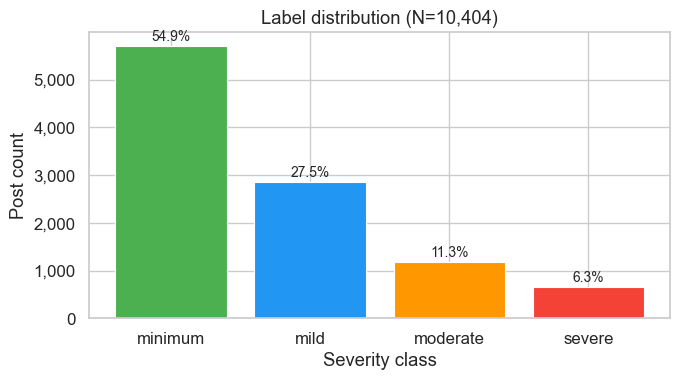

In [3]:
label_counts = df['label'].value_counts().reindex(LABEL_ORDER)
label_pct    = (label_counts / len(df) * 100).round(1)

label_table = pd.DataFrame({"Count": label_counts, "%": label_pct})
print(label_table.to_string())
print(f"\nImbalance ratio (minimum:severe) = {label_counts['minimum']/label_counts['severe']:.1f}:1")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(LABEL_ORDER, label_counts, color=LABEL_COLOURS, edgecolor='white', linewidth=0.8)
for bar, pct in zip(bars, label_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{pct}%', ha='center', va='bottom', fontsize=10)
ax.set_xlabel("Severity class")
ax.set_ylabel("Post count")
ax.set_title("Label distribution (N=10,404)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(FIG_DIR / "label_distribution.png", dpi=150)
plt.show()

---
## 3. Source Distribution & Platform × Label Breakdown

The dataset is dominated by **Twitter (86%)**, with Reddit contributing 14%.  
Crucially, **severity distributions differ substantially between platforms**:  
Twitter skews heavily toward *minimum* (58.5%), while Reddit has a far more even spread  
with proportionally much more *moderate* (27.6%) and *severe* (19.7%) posts.

A model trained on this combined set learns a Twitter-shaped class prior, directly impacting  
per-platform generalisation and motivating the per-platform evaluation slice.

Source distribution:
         count   pct
source              
twitter   8979  86.3
reddit    1425  13.7

Absolute counts (source × label):
label    minimum  mild  moderate  severe
source                                  
reddit       460   290       394     281
twitter     5254  2567       782     376

Row-normalised — label % within each source:
label    minimum  mild  moderate  severe
source                                  
reddit      32.3  20.4      27.6    19.7
twitter     58.5  28.6       8.7     4.2


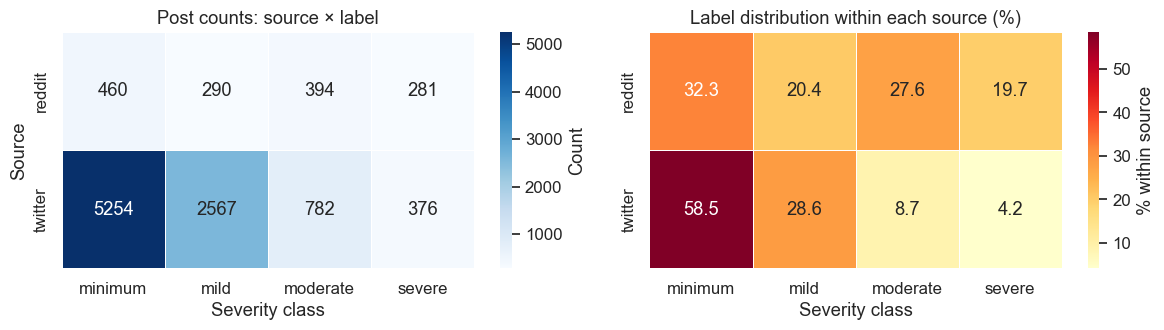

In [4]:
src_counts = df['source'].value_counts()
print("Source distribution:")
print(src_counts.to_frame('count').assign(pct=(src_counts / len(df) * 100).round(1)))
print()

ct_abs = pd.crosstab(df['source'], df['label'])[LABEL_ORDER]
print("Absolute counts (source × label):")
print(ct_abs)
print()

ct_pct = pd.crosstab(df['source'], df['label'], normalize='index')[LABEL_ORDER] * 100
print("Row-normalised — label % within each source:")
print(ct_pct.round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

sns.heatmap(ct_abs, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            linewidths=0.5, cbar_kws={"label": "Count"})
axes[0].set_title("Post counts: source × label")
axes[0].set_xlabel("Severity class"); axes[0].set_ylabel("Source")

sns.heatmap(ct_pct.round(1), annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1],
            linewidths=0.5, cbar_kws={"label": "% within source"})
axes[1].set_title("Label distribution within each source (%)")
axes[1].set_xlabel("Severity class"); axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(FIG_DIR / "source_label_heatmap.png", dpi=150)
plt.show()

---
## 4. Text Length Analysis

Two clear patterns emerge:  
- **Severity correlates with length**: *severe* posts are ~63% longer than *minimum* posts  
  (median: 49 words vs 30). Moderate and severe users tend to elaborate more.  
  Note: *mild* (27 words) dips slightly below *minimum* (30), likely due to brief venting posts;  
  the overall trend across the more-severe classes is clear.  
- **Reddit posts are ~3x longer than Twitter posts** (median 82 vs 28 words),  
  reflecting platform affordances (character limit vs free-form). This length difference  
  contributes to the platform performance gap seen in notebook 09.

Length by label:
         word_count              char_count              
               mean median   std       mean median    std
label                                                    
minimum        33.4   30.0  21.6      177.4  161.0  114.9
mild           33.5   27.0  26.3      173.7  136.0  137.3
moderate       53.6   48.0  33.1      280.7  256.0  173.4
severe         57.5   49.0  37.2      298.3  270.0  190.1

Length by source:
        word_count        char_count       
              mean median       mean median
source                                     
reddit        87.1   82.0      453.3  426.0
twitter       29.3   28.0      154.8  145.0


C:\Users\Nolan\AppData\Local\Temp\ipykernel_30984\757034375.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='label', y='word_count',
C:\Users\Nolan\AppData\Local\Temp\ipykernel_30984\757034375.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='source', y='word_count',


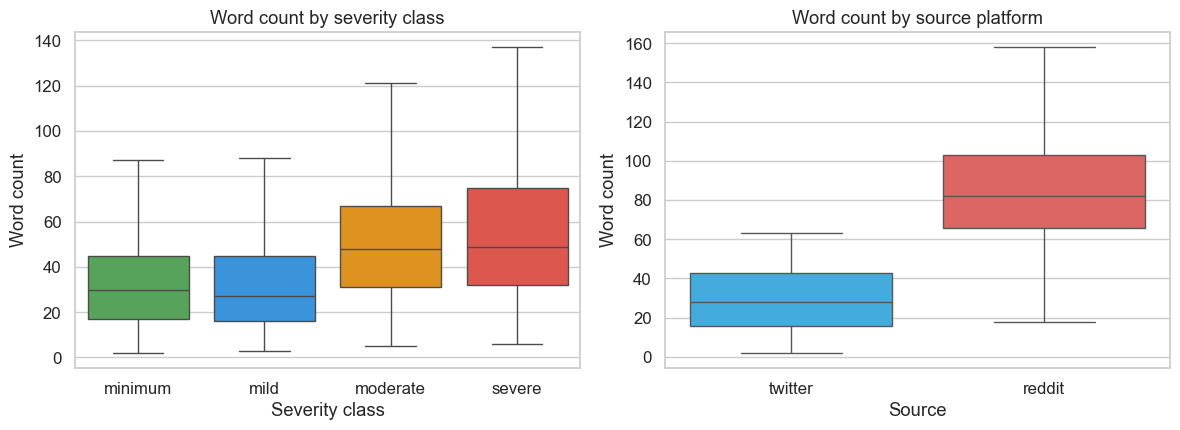

In [5]:
df['word_count'] = df['text'].str.split().str.len()
df['char_count']  = df['text'].str.len()

len_by_label = (
    df.groupby('label')[['word_count', 'char_count']]
    .agg(['mean', 'median', 'std'])
    .round(1)
    .reindex(LABEL_ORDER)
)
print("Length by label:")
print(len_by_label)
print()

len_by_src = df.groupby('source')[['word_count', 'char_count']].agg(['mean', 'median']).round(1)
print("Length by source:")
print(len_by_src)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

df_plot = df.copy()
df_plot['label'] = pd.Categorical(df_plot['label'], categories=LABEL_ORDER, ordered=True)
sns.boxplot(data=df_plot, x='label', y='word_count',
            palette=LABEL_COLOURS, order=LABEL_ORDER, showfliers=False, ax=axes[0])
axes[0].set_title("Word count by severity class")
axes[0].set_xlabel("Severity class"); axes[0].set_ylabel("Word count")

sns.boxplot(data=df, x='source', y='word_count',
            palette=['#29B6F6', '#EF5350'], showfliers=False, ax=axes[1])
axes[1].set_title("Word count by source platform")
axes[1].set_xlabel("Source"); axes[1].set_ylabel("Word count")

plt.tight_layout()
plt.savefig(FIG_DIR / "text_length.png", dpi=150)
plt.show()

---
## 5. Class Imbalance & Class-Weight Derivation

All models use `sklearn` balanced class weights derived from the **training set only**.  
*Severe* receives roughly 7× the weight of *minimum*, counteracting the 8.7:1 raw imbalance.

In [6]:
from sklearn.utils.class_weight import compute_class_weight
from src.data import load_splits

train_df, val_df, test_df = load_splits()
print(f"Split sizes — Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print(f"Total: {len(train_df)+len(val_df)+len(test_df):,}")
print()

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2, 3]),
    y=train_df['label_id'].values,
)
weight_df = pd.DataFrame({
    'label':   LABEL_ORDER,
    'train_n': [train_df[train_df['label_id']==i].shape[0] for i in range(4)],
    'weight':  weights.round(4),
})
print("Class weights (train set):")
print(weight_df.to_string(index=False))
print()
print(f"*severe* receives {weights[3]/weights[0]:.1f}x the weight of *minimum*")

Split sizes — Train: 8,323 | Val: 1,040 | Test: 1,041
Total: 10,404

Class weights (train set):
   label  train_n  weight
 minimum     4571  0.4552
    mild     2285  0.9106
moderate      941  2.2112
  severe      526  3.9558

*severe* receives 8.7x the weight of *minimum*


---
## 6. Informality Score Distribution

The **informality score** (fraction of tokens that are emoji, all-caps, or contain repeated characters  
such as *soooo* or *!!!*) operationalises the internet-slang dimension central to H2.  
GloVe OOV tokens are also included when `data/glove.6B.300d.txt` is present on disk.

Expected: Twitter > Reddit (shorter, punchier, more emoji); informality should be roughly  
independent of severity class (style feature, not content feature).

16:48:34  INFO      src.slang — Loading GloVe vocabulary from C:\Users\Nolan\Documents\GitHub\Capstone-Group-3\data\glove.6B.300d.txt ...
16:48:36  INFO      src.slang — GloVe vocabulary size: 400,000
16:48:36  INFO      src.slang — Computing informality scores for 10,404 posts ...
16:48:36  INFO      src.slang — Informality bins — low: 3656  mid: 3337  high: 3411  (score range 0.000–1.619)


Informality score by source:
          count    mean     std     min     25%     50%     75%    max
source                                                                
reddit   1425.0  0.1457  0.0501  0.0161  0.1124  0.1395  0.1736  0.480
twitter  8979.0  0.1589  0.1246  0.0000  0.0866  0.1429  0.2045  1.619

Mean informality score by label:
label
minimum     0.1639
mild        0.1465
moderate    0.1554
severe      0.1473
Name: informality_score, dtype: float64

Bin distribution by source:
informality_bin   low   mid  high
source                           
reddit            352   743   330
twitter          3304  2594  3081

Mean component counts by source:
         n_emoji  n_allcaps  n_repeated  n_oov
source                                        
reddit     0.000      0.248        0.00  11.79
twitter    0.004      0.365        0.13   4.11


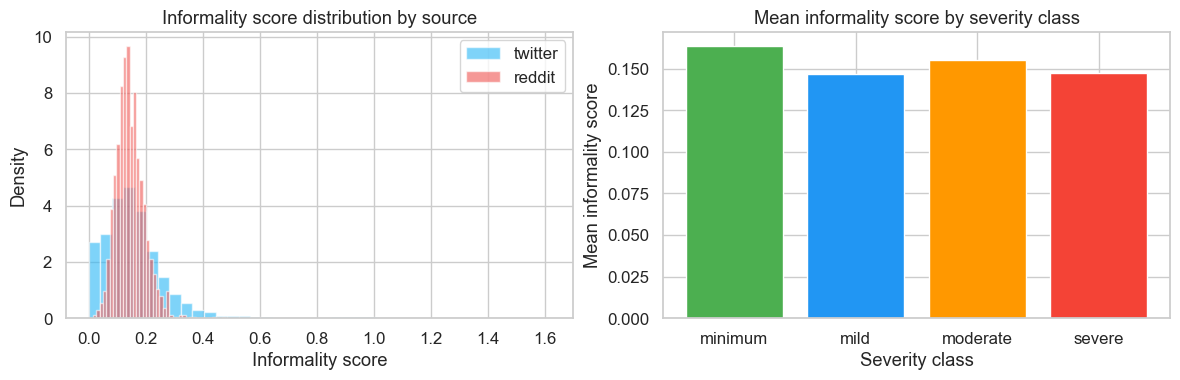

In [7]:
df_inf = add_informality_score(df, include_components=True)

print("Informality score by source:")
print(df_inf.groupby('source')['informality_score'].describe().round(4))
print()

print("Mean informality score by label:")
print(df_inf.groupby('label')['informality_score'].mean().reindex(LABEL_ORDER).round(4))
print()

print("Bin distribution by source:")
print(pd.crosstab(df_inf['source'], df_inf['informality_bin'])[['low', 'mid', 'high']])

comp_cols = [c for c in ['n_emoji', 'n_allcaps', 'n_repeated', 'n_oov'] if c in df_inf.columns]
if comp_cols:
    print("\nMean component counts by source:")
    print(df_inf.groupby('source')[comp_cols].mean().round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for src, col in zip(['twitter', 'reddit'], ['#29B6F6', '#EF5350']):
    vals = df_inf[df_inf['source'] == src]['informality_score']
    axes[0].hist(vals, bins=40, alpha=0.6, color=col, label=src, density=True)
axes[0].set_xlabel("Informality score")
axes[0].set_ylabel("Density")
axes[0].set_title("Informality score distribution by source")
axes[0].legend()

means_by_label = df_inf.groupby('label')['informality_score'].mean().reindex(LABEL_ORDER)
axes[1].bar(LABEL_ORDER, means_by_label, color=LABEL_COLOURS, edgecolor='white')
axes[1].set_xlabel("Severity class")
axes[1].set_ylabel("Mean informality score")
axes[1].set_title("Mean informality score by severity class")

plt.tight_layout()
plt.savefig(FIG_DIR / "informality_distribution.png", dpi=150)
plt.show()

---
## 7. Representative Examples Per Class

A hand-checked sample illustrates the linguistic range within each severity level.

In [8]:
pd.set_option("display.max_colwidth", 200)

for label in LABEL_ORDER:
    print(f"\n{'='*70}")
    print(f"  CLASS: {label.upper()}")
    print(f"{'='*70}")
    sample = (
        df[df['label'] == label]
        .sample(3, random_state=42)[['source', 'text']]
        .reset_index(drop=True)
    )
    for _, row in sample.iterrows():
        print(f"  [{row['source']}] {row['text'][:200]}")
        print()

pd.reset_option("display.max_colwidth")


  CLASS: MINIMUM
  [twitter] I got tired of their bs lol

  [twitter] Model Machine: The perfect machine doesn't get tired and always gets the timing right.

  [twitter] guys I wanna watch hyunjin’s aotm but I’m tired since I’ve been out the whole day and i just got back, I wanna enjoy it so I’ll be coming back to freak out tomorrow


  CLASS: MILD
  [twitter] i haven’t seen jared since august 2019 i’m so depressed

  [twitter] i be so drained after work i just be wanting time to myself sometimes

  [twitter] I swear if I ruined my laptop I'm going to be even more severely depressed then I already am I'll be the ultimate failure


  CLASS: MODERATE
  [twitter] Woke up this morning with the "no one would even miss me if I were gone" thoughts going on. Not that they're wrong. I'm just feeling so very drained of life today. Everyone disappears and forgets you.

  [reddit] I was trying to eat my food but my hands became shaky and i then didnt feel hungry. People kept asking me why my hand

---
## 8. Key Findings Summary

| Finding | Value | Design implication |
|---|---|---|
| Total posts | 10,404 | — |
| Class imbalance | 8.7:1 (minimum:severe) | Balanced class weights in all models |
| Twitter share | 86.3% (8,979 posts) | Twitter-dominant training prior |
| Reddit share | 13.7% (1,425 posts) | Small slice → wider CIs on Reddit metrics |
| Twitter severity | 58.5% minimum / 4.2% severe | Models see little severe signal from Twitter |
| Reddit severity | 32.3% minimum / 19.7% severe | Reddit more balanced — harder to generalise to |
| Median words: Twitter | 28 | Short, punchy register |
| Median words: Reddit | 82 | ~3× longer, more elaborate |
| Length vs severity | min=30, mild=27, mod=48, severe=49 words | Broadly increasing (mild dip); severity correlates with elaboration |
| Informality | Higher in Twitter than Reddit | Motivates H2 informality × platform analysis |

**Platform gap interpretation** (relevant to H2 / Discussion): the performance drop from Twitter  
to Reddit observed in notebook 09 is primarily attributable to the **training distribution mismatch**  
(86% Twitter), not to informality per se. Reddit posts are longer *and* more severity-balanced,  
making them inherently harder for a model trained on Twitter-dominant data.